In [ ]:
!pip -q install kagglehub

import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import kagglehub

In [ ]:
path = kagglehub.dataset_download("shayanfazeli/heartbeat")

train_source = os.path.join(path, "mitbih_train.csv")
test_source = os.path.join(path, "mitbih_test.csv")

shutil.copy(train_source, "mitbih_train.csv")
shutil.copy(test_source, "mitbih_test.csv")

print("Training file exists:", os.path.exists("mitbih_train.csv"))
print("Test file exists    :", os.path.exists("mitbih_test.csv"))

Using Colab cache for faster access to the 'heartbeat' dataset.
Training file exists: True
Test file exists    : True


In [ ]:
BEAT_LENGTH = 187
BATCH_SIZE = 64
EPOCHS = 20
SAMPLE_RATE = 125

class_names = [
    "Normal Beat",
    "Supraventricular Ectopic Beat",
    "Ventricular Ectopic Beat",
    "Fusion Beat",
    "Unknown Beat"
]

In [ ]:
train_df = pd.read_csv("mitbih_train.csv")
test_df = pd.read_csv("mitbih_test.csv")

print("Training file shape:", train_df.shape)
print("Test file shape:", test_df.shape)

print("\nMissing values:", train_df.isnull().sum().sum())

print("\nTraining class counts:")
print(train_df.iloc[:, -1].value_counts().sort_index())

Training file shape: (87553, 188)
Test file shape: (21891, 188)

Missing values: 0

Training class counts:
0.000000000000000000e+00.88
0.0    72470
1.0     2223
2.0     5788
3.0      641
4.0     6431
Name: count, dtype: int64


In [ ]:
X = train_df.iloc[:, :BEAT_LENGTH].values.astype(np.float32)
y = train_df.iloc[:, BEAT_LENGTH].values.astype(np.int32)

X_test = test_df.iloc[:, :BEAT_LENGTH].values.astype(np.float32)
y_test = test_df.iloc[:, BEAT_LENGTH].values.astype(np.int32)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Test X shape:", X_test.shape)
print("Test y shape:", y_test.shape)

X shape: (87553, 187)
y shape: (87553,)
Test X shape: (21891, 187)
Test y shape: (21891,)


In [ ]:
X_max = np.max(X, axis=1, keepdims=True)
X_max[X_max == 0] = 1
X = X / X_max

X_test_max = np.max(X_test, axis=1, keepdims=True)
X_test_max[X_test_max == 0] = 1
X_test = X_test / X_test_max

print("Normalization completed.")

Normalization completed.


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 78797
Validation samples: 8756
Test samples: 21891


In [ ]:
X_train = X_train.reshape(-1, BEAT_LENGTH, 1)
X_val = X_val.reshape(-1, BEAT_LENGTH, 1)
X_test_cnn = X_test.reshape(-1, BEAT_LENGTH, 1)

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test_cnn.shape)

Training shape: (78797, 187, 1)
Validation shape: (8756, 187, 1)
Test shape: (21891, 187, 1)


In [ ]:
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

class_weights = {
    key: np.sqrt(value)
    for key, value in class_weights.items()
}

print("Class weights:")
print(class_weights)

Class weights:
{np.int32(0): np.float64(0.49155575304795585), np.int32(1): np.float64(2.8063788266983005), np.int32(2): np.float64(1.7393727451452266), np.int32(3): np.float64(5.226150748538272), np.int32(4): np.float64(1.6500821951841842)}


In [ ]:
model = Sequential([

    Conv1D(
        32,
        5,
        padding="same",
        activation="relu",
        input_shape=(187, 1)
    ),

    MaxPooling1D(2),

    Conv1D(
        64,
        5,
        padding="same",
        activation="relu"
    ),

    MaxPooling1D(2),

    Conv1D(
        128,
        3,
        padding="same",
        activation="relu"
    ),

    MaxPooling1D(2),

    Flatten(),

    Dense(64, activation="relu"),

    Dropout(0.3),

    Dense(5, activation="softmax")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 187, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 93, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 93, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 46, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 46, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       188,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,005 (875.02 KB)

 Trainable params: 224,005 (875.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 55s 43ms/step - accuracy: 0.9186 - loss: 0.3351 - val_accuracy: 0.9535 - val_loss: 0.1743
Epoch 2/20
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - accuracy: 0.9510 - loss: 0.2023 - val_accuracy: 0.9647 - val_loss: 0.1129
Epoch 3/20
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 53s 43ms/step - accuracy: 0.9606 - loss: 0.1606 - val_accuracy: 0.9757 - val_loss: 0.0842
Epoch 4/20
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 54s 44ms/step - accuracy: 0.9650 - loss: 0.1377 - val_accuracy: 0.9697 - val_loss: 0.1325
Epoch 5/20
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 81s 42ms/step - accuracy: 0.9666 - loss: 0.1205 - val_accuracy: 0.9782 - val_loss: 0.0691
Epoch 6/20
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 53s 43ms/step - accuracy: 0.9700 - loss: 0.1049 - val_accuracy: 0.9828 - val_loss: 0.0571
Epoch 7/20
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 51s 41ms/step - accuracy: 0.9717 - loss: 0.1004 - val_accuracy: 0.9801 - val_loss: 0.0638
Epoch 8/20
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 54s 43ms/step - accuracy: 0.9734 -

In [ ]:
best_epoch = np.argmin(
    history.history["val_loss"]
) + 1

print("Best Epoch:", best_epoch)

print(
    "Training Accuracy:",
    f"{history.history['accuracy'][best_epoch-1] * 100:.2f}%"
)

print(
    "Validation Accuracy:",
    f"{history.history['val_accuracy'][best_epoch-1] * 100:.2f}%"
)

print(
    "Training Loss:",
    f"{history.history['loss'][best_epoch-1]:.4f}"
)

print(
    "Validation Loss:",
    f"{history.history['val_loss'][best_epoch-1]:.4f}"
)

Best Epoch: 6
Training Accuracy: 97.00%
Validation Accuracy: 98.28%
Training Loss: 0.1049
Validation Loss: 0.0571


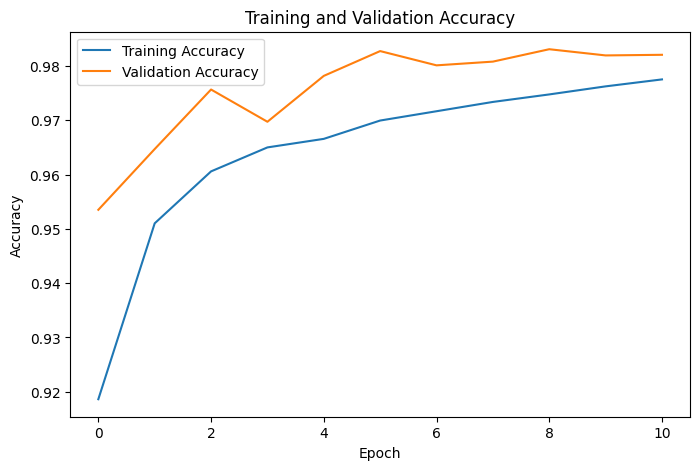

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

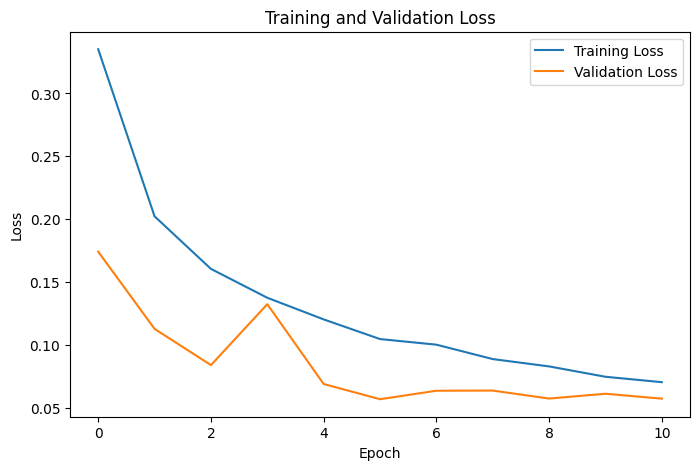

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test_cnn,
    y_test,
    verbose=0
)

print("=" * 50)
print("TEST RESULTS")
print("=" * 50)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

TEST RESULTS
Test Loss     : 0.0775
Test Accuracy : 97.90%


In [ ]:
y_probability = model.predict(
    X_test_cnn,
    verbose=0
)

y_pred = np.argmax(
    y_probability,
    axis=1
)

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[17917    86    68    20    26]
 [  121   419    11     3     2]
 [   37     4  1381    23     3]
 [   19     1    14   128     0]
 [   13     1     8     0  1586]]


In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

                               precision    recall  f1-score   support

                  Normal Beat     0.9895    0.9890    0.9892     18117
Supraventricular Ectopic Beat     0.8200    0.7536    0.7854       556
     Ventricular Ectopic Beat     0.9318    0.9537    0.9427      1448
                  Fusion Beat     0.7356    0.7901    0.7619       162
                 Unknown Beat     0.9808    0.9863    0.9836      1608

                     accuracy                         0.9790     21891
                    macro avg     0.8916    0.8945    0.8925     21891
                 weighted avg     0.9789    0.9790    0.9789     21891



In [ ]:
model.save("ecg_1d_cnn_model.keras")

print("Model saved successfully.")

Model saved successfully.


In [1]:
from IPython.display import display
import ipywidgets as widgets
import numpy as np

ecg_input = widgets.Textarea(
    placeholder="Paste exactly 187 ECG values here...",
    description="ECG:",
    layout=widgets.Layout(
        width="100%",
        height="150px"
    )
)

predict_button = widgets.Button(
    description="PREDICT",
    button_style="success",
    layout=widgets.Layout(
        width="150px",
        height="40px"
    )
)

prediction_output = widgets.Output()

display(ecg_input)
display(predict_button)
display(prediction_output)


def predict_manual_ecg(button):

    with prediction_output:

        prediction_output.clear_output()

        try:

            values = np.array(
                [
                    float(x)
                    for x in ecg_input.value.split()
                ],
                dtype=np.float32
            )

        except ValueError:

            print("ERROR: Please enter numerical values only.")
            return

        if len(values) != 187:

            print("ERROR!")
            print("Number of values entered:", len(values))
            print("Please enter exactly 187 values.")
            return

        maximum = np.max(values)

        if maximum != 0:
            values = values / maximum

        sample = values.reshape(1, 187, 1)

        probabilities = model.predict(
            sample,
            verbose=0
        )[0]

        predicted_index = np.argmax(probabilities)

        predicted_class = class_names[predicted_index]

        confidence = (
            probabilities[predicted_index] * 100
        )

        print("=" * 60)
        print("ECG HEARTBEAT CLASSIFICATION RESULT")
        print("=" * 60)

        print("Number of values :", len(values))
        print("Predicted Class  :", predicted_class)
        print(f"Confidence       : {confidence:.2f}%")

        print("\nClass Probabilities:")

        for i in range(5):

            print(
                f"{class_names[i]:35s} : "
                f"{probabilities[i] * 100:.2f}%"
            )

        print("=" * 60)


predict_button.on_click(predict_manual_ecg)

Textarea(value='', description='ECG:', layout=Layout(height='150px', width='100%'), placeholder='Paste exactly…

Button(button_style='success', description='PREDICT', layout=Layout(height='40px', width='150px'), style=Butto…

Output()

ECG HEARTBEAT CLASSIFICATION RESULT
Number of ECG values : 187
Predicted Class      : Normal Beat
Confidence           : 99.27%


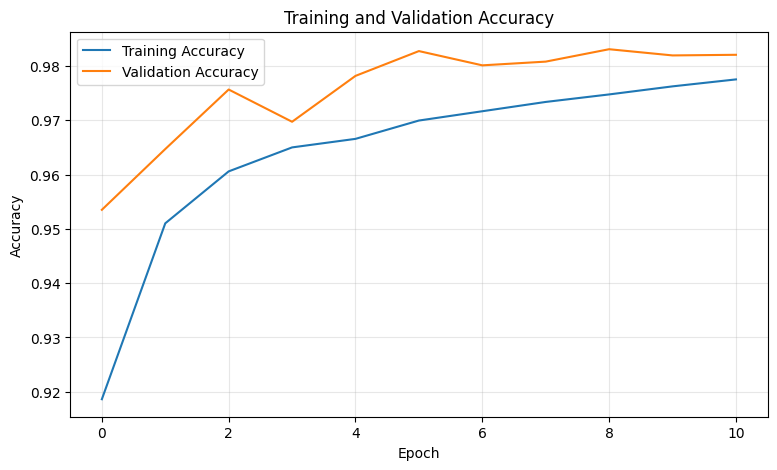

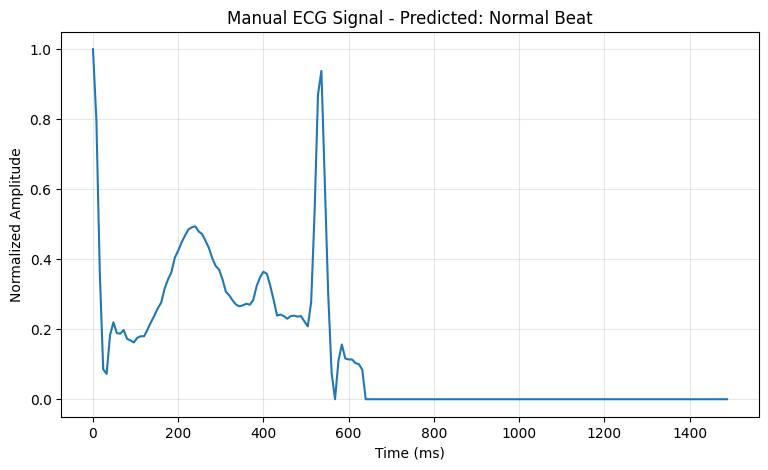

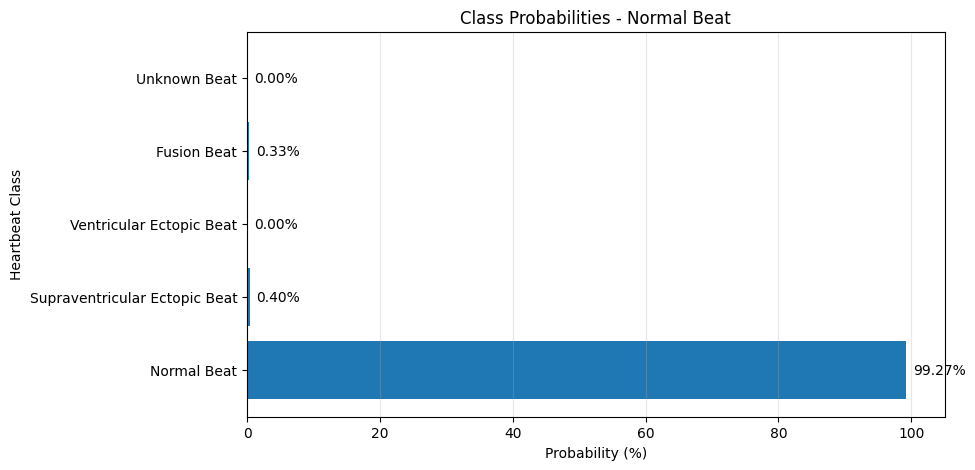

In [ ]:
from IPython.display import display
import ipywidgets as widgets
import numpy as np
import matplotlib.pyplot as plt

# ---------------- CLASS NAMES ----------------

class_names = [
    "Normal Beat",
    "Supraventricular Ectopic Beat",
    "Ventricular Ectopic Beat",
    "Fusion Beat",
    "Unknown Beat"
]


# ---------------- INPUT BOX ----------------

ecg_input = widgets.Textarea(
    placeholder="Paste exactly 187 ECG values separated by spaces...",
    description="ECG:",
    layout=widgets.Layout(
        width="100%",
        height="150px"
    )
)

predict_button = widgets.Button(
    description="PREDICT",
    button_style="success",
    layout=widgets.Layout(
        width="150px",
        height="40px"
    )
)

output = widgets.Output()

display(ecg_input)
display(predict_button)
display(output)


# ---------------- PREDICTION FUNCTION ----------------

def predict_manual_ecg(button):

    with output:

        output.clear_output()

        try:

            values = np.array(
                [
                    float(x)
                    for x in ecg_input.value.split()
                ],
                dtype=np.float32
            )

        except ValueError:

            print("ERROR: Enter numerical values only.")
            return


        # Check exactly 187 values

        if len(values) != 187:

            print("ERROR!")
            print("Number of values entered:", len(values))
            print("Please enter exactly 187 values.")
            return


        # Normalize

        maximum = np.max(values)

        if maximum != 0:
            values = values / maximum


        # Reshape for CNN

        sample = values.reshape(1, 187, 1)


        # Predict

        probabilities = model.predict(
            sample,
            verbose=0
        )[0]

        predicted_index = np.argmax(probabilities)

        predicted_class = class_names[predicted_index]

        confidence = probabilities[predicted_index] * 100


        # ---------------- RESULT ----------------

        print("=" * 70)
        print("ECG HEARTBEAT CLASSIFICATION RESULT")
        print("=" * 70)

        print("Number of ECG values :", len(values))
        print("Predicted Class      :", predicted_class)
        print(f"Confidence           : {confidence:.2f}%")

        print("=" * 70)


        # ==================================================
        # GRAPH 1 — TRAINING / VALIDATION ACCURACY
        # ==================================================

        plt.figure(figsize=(9, 5))

        plt.plot(
            history.history["accuracy"],
            label="Training Accuracy"
        )

        plt.plot(
            history.history["val_accuracy"],
            label="Validation Accuracy"
        )

        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Training and Validation Accuracy")

        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.show()


        # ==================================================
        # GRAPH 2 — MANUAL ECG WAVEFORM
        # ==================================================

        time = np.arange(187) / SAMPLE_RATE * 1000

        plt.figure(figsize=(9, 5))

        plt.plot(
            time,
            values
        )

        plt.xlabel("Time (ms)")
        plt.ylabel("Normalized Amplitude")

        plt.title(
            f"Manual ECG Signal - Predicted: {predicted_class}"
        )

        plt.grid(True, alpha=0.3)

        plt.show()


        # ==================================================
        # GRAPH 3 — CLASS PROBABILITIES
        # ==================================================

        probability_percent = probabilities * 100

        plt.figure(figsize=(9, 5))

        bars = plt.barh(
            class_names,
            probability_percent
        )

        plt.xlabel("Probability (%)")
        plt.ylabel("Heartbeat Class")

        plt.title(
            f"Class Probabilities - {predicted_class}"
        )

        plt.xlim(0, 105)

        for bar, probability in zip(
            bars,
            probability_percent
        ):

            plt.text(
                probability + 1,
                bar.get_y() + bar.get_height() / 2,
                f"{probability:.2f}%",
                va="center"
            )

        plt.grid(
            axis="x",
            alpha=0.3
        )

        plt.show()


# ---------------- BUTTON ACTION ----------------

predict_button.on_click(
    predict_manual_ecg
)